In [53]:
import numpy as np
import pandas as pd
import tkinter as tk
from tkinter import ttk, filedialog, BooleanVar
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
import chardet
from pathlib import Path
from glob import glob
from sklearn.metrics import r2_score
from IPython.display import display

In [54]:
class SpectraReader:
    def __init__(self, file_path, tol=1e-6, min_freq=200, max_freq=2000):
        self.file_path = Path(file_path)
        self.tol = tol
        self.min_freq = min_freq
        self.max_freq = max_freq
        self.title = self._make_title()
        self.groups = self._read_file()
        self.gaps = self.detect_band_gaps()

    def _make_title(self):
        name = self.file_path.stem
        name = name.replace('_', ' ').replace('-', ' ')
        name = name.replace('mm', ' mm')
        return name.capitalize()

    def _detect_encoding(self):
        with open(self.file_path, 'rb') as f:
            return chardet.detect(f.read())['encoding']

    def _find_data_start(self, encoding):
        with open(self.file_path, 'r', encoding=encoding) as f:
            for i, line in enumerate(f):
                if line.strip() and line.strip()[0].isdigit():
                    return i
        raise ValueError("No numeric data found in the file.")

    def _read_file(self):
        encoding = self._detect_encoding()
        start_row = self._find_data_start(encoding)

        df = pd.read_csv(
            self.file_path,
            skiprows=start_row,
            sep=r'\s+',
            header=None,
            encoding=encoding
        )
        df.columns = ['kxa (rad)', 'Frequency (Hz)']

        # Group by kxa == 0
        group_id = (df['kxa (rad)'] == 0).cumsum()
        grouped = [
            g.reset_index(drop=True)
            for _, g in df.groupby(group_id)
            if len(g) > 3
        ]

        # Filter frequencies within 20–2000 Hz
        filtered_groups = []
        for g in grouped:
            g_filtered = g[(g['Frequency (Hz)'] >= self.min_freq) & (g['Frequency (Hz)'] <= self.max_freq)]
            if len(g_filtered) > 0:
                filtered_groups.append(g_filtered.reset_index(drop=True))

        return filtered_groups

    def detect_band_gaps(self):
        band_edges = []

        # Collect min/max of each group
        for group in self.groups:
            f = group['Frequency (Hz)'].values
            band_edges.append((f.min(), f.max()))

        # Add limits as artificial edges
        band_edges.append((self.min_freq, self.min_freq))
        band_edges.append((self.max_freq, self.max_freq))

        # Sort by lower edge
        band_edges.sort(key=lambda x: x[0])

        # Detect gaps
        gaps = []
        for (low1, high1), (low2, high2) in zip(band_edges[:-1], band_edges[1:]):
            if low2 - high1 > self.tol:
                gaps.append((high1, low2))

        # Clip gaps to 20–2000 Hz
        gaps_clipped = [(max(self.min_freq, g[0]), min(self.max_freq, g[1])) for g in gaps if g[1] > self.min_freq and g[0] < self.max_freq]

        return gaps_clipped

    def total_band_gap(self):
        return sum(g[1] - g[0] for g in self.gaps)

    # ----------------------------
    # UPDATED PLOT METHOD
    # ----------------------------
    def plot(self):
        fig, ax = plt.subplots(figsize=(8, 6))

        x_min = min(g['kxa (rad)'].min() for g in self.groups)
        x_max = max(g['kxa (rad)'].max() for g in self.groups)

        # ---- SHADE ENTIRE FREQUENCY RANGE FIRST ----
        ax.axhspan(self.min_freq, self.max_freq, color='grey', alpha=0.25, zorder=0)

        # Plot each group on top
        for group in self.groups:
            ax.plot(
                group['kxa (rad)'],
                group['Frequency (Hz)'],
                color='black',
                linewidth=1,
                zorder=2
            )

        # ---- “UNSHADE” THE ACTUAL BAND GAPS ----
        for gap_start, gap_end in self.gaps:
            ax.axhspan(gap_start, gap_end, color='white', alpha=1.0, zorder=1)
            ax.hlines([gap_start, gap_end], x_min, x_max, linestyles='dotted', colors='red', linewidth=1)

        # Add horizontal lines at min/max frequency
        ax.hlines([self.min_freq, self.max_freq],
                  x_min, x_max,
                  linestyles='solid',
                  colors='blue',
                  linewidth=1,
                  label='Freq limits')

        ax.set_xlabel(r'$k_x a_x$ (rad)')
        ax.set_ylabel('Frequency (Hz)')
        ax.set_title(self.title)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(self.min_freq, self.max_freq)
        ax.legend()
        plt.tight_layout()
        plt.show()

    def extract_thickness(self):
        for token in self.file_path.stem.split():
            if 'mm' in token:
                return float(token.replace('mm', ''))
        raise ValueError("Thickness not found in filename.")


In [ ]:
class BandGapAnalyzer:
    def __init__(self, folder: str, param_name: str, plot_spectra: bool = False):
        """
        folder: str, path to folder containing TXT files
        param_name: str, name of the physical variable (e.g., 'Thickness (mm)')
        plot_spectra: bool, whether to plot individual spectra
        """
        self.folder = Path(folder)
        self.param_name = param_name
        self.plot_spectra = plot_spectra
        self.data = None
        self._collect_data()

    def _collect_data(self, display_data: bool = False):
        """Scan folder, read spectra, and compute total band gaps."""
        records = []
        for file in self.folder.glob('*.txt'):
            spec = SpectraReader(file)
            if self.plot_spectra:
                spec.plot()
            # Parameter extraction logic (can adjust per variable type)
            param_value = spec.extract_thickness()  # modify if needed for separation/slit
            records.append({
                self.param_name: param_value,
                'Total Band Gap (Hz)': spec.total_band_gap()
            })
        self.data = pd.DataFrame(records).sort_values(self.param_name).reset_index(drop=True)
        if display_data:
            display(self.data)

    def best_fit(self, degrees=(1, 2, 3)):
        """Compute polynomial fit and return best degree based on R²."""
        x = self.data[self.param_name].values
        y = self.data['Total Band Gap (Hz)'].values

        best_r2 = -np.inf
        best_degree = None
        best_coeffs = None
        best_y_fit = None

        for deg in degrees:
            coeffs = np.polyfit(x, y, deg)
            y_fit = np.polyval(coeffs, x)
            r2 = r2_score(y, y_fit)
            if r2 > best_r2:
                best_r2 = r2
                best_degree = deg
                best_coeffs = coeffs
                best_y_fit = y_fit

        return best_degree, best_coeffs, best_r2

    def plot(self, show_plot: bool = True, fit_plot: bool = True):
        """Plot Total Band Gap vs parameter, optionally with polynomial fit."""
        if self.data is None or self.data.empty:
            raise ValueError("No data available to plot.")

        x = self.data[self.param_name].values
        y = self.data['Total Band Gap (Hz)'].values

        if not show_plot:
            return
        
        plt.figure(figsize=(8, 6))
        plt.scatter(x, y, color='blue', label='Simulation data')

        if fit_plot:
            best_degree, best_coeffs, best_r2 = self.best_fit()
            x_smooth = np.linspace(x.min(), x.max(), 200)
            y_smooth = np.polyval(best_coeffs, x_smooth)
            plt.plot(x_smooth, y_smooth, color='red', linestyle='--',
                     label=f'Polynomial fit (deg {best_degree}, R²={best_r2:.3f})')

        plt.xlabel(self.param_name)
        plt.ylabel('Total Band Gap (Hz)')
        plt.title(f'Band Gap vs {self.param_name}')
        plt.legend()
        plt.show()

: 

2026-01-21 10:37:07.827 Python[6732:6201447] ApplePersistenceIgnoreState: Existing state will not be touched. New state will be written to /var/folders/6h/7s35f_mj3cdg5w_9vf9glqxr0000gn/T/org.python.python.savedState


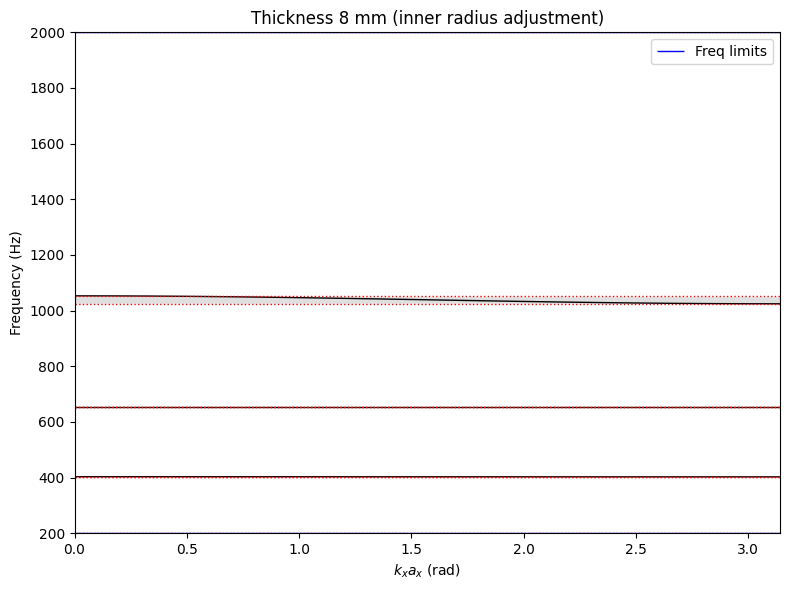

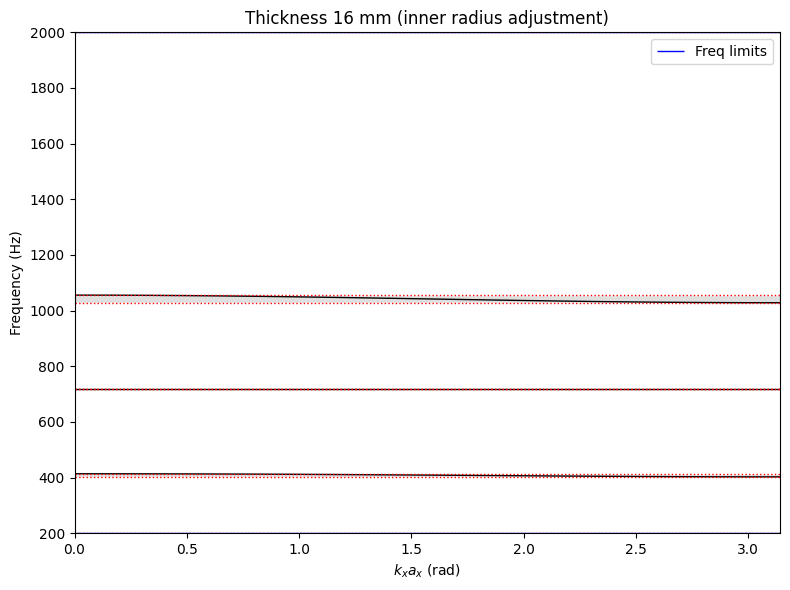

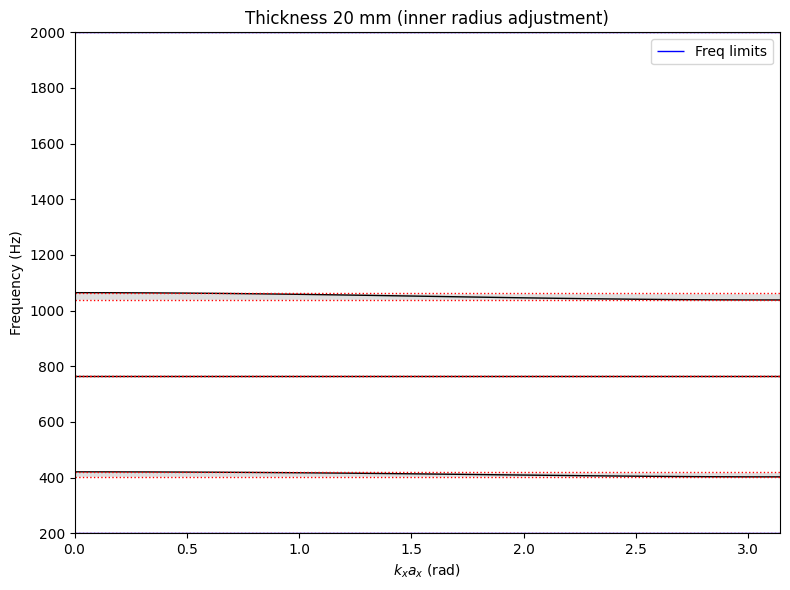

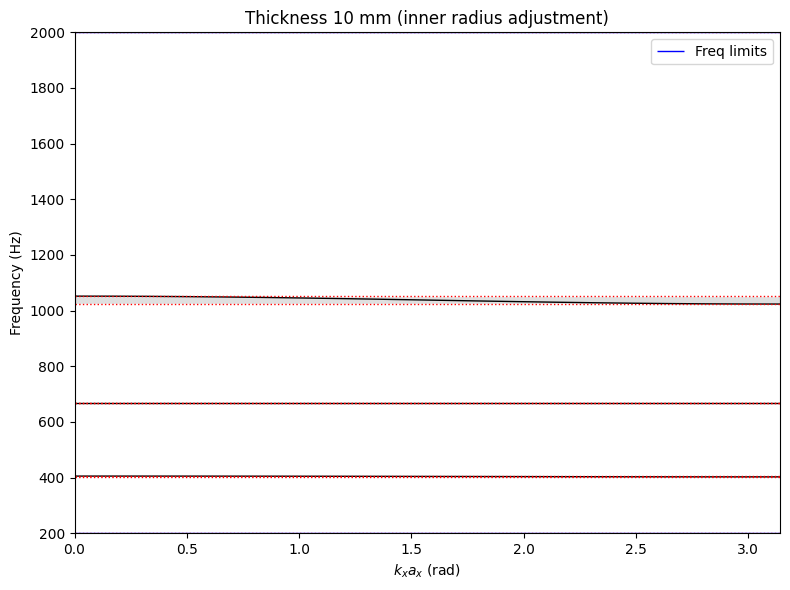

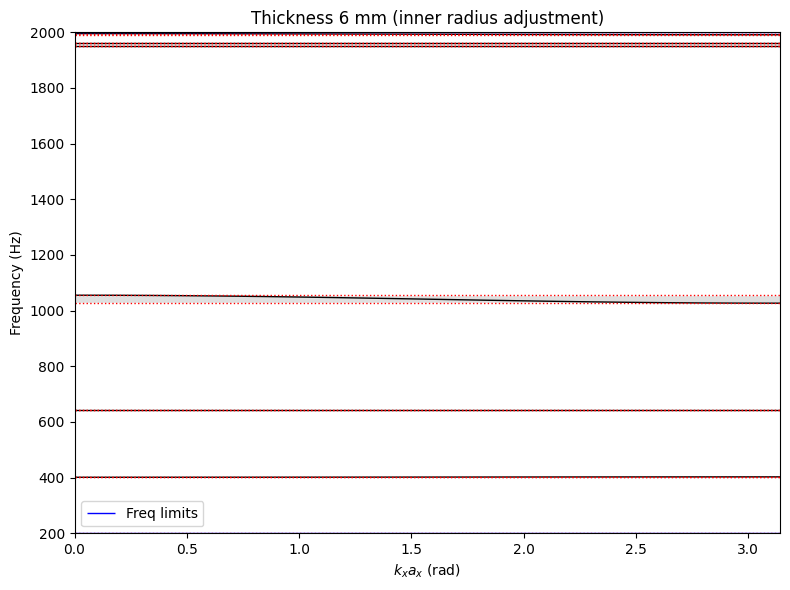

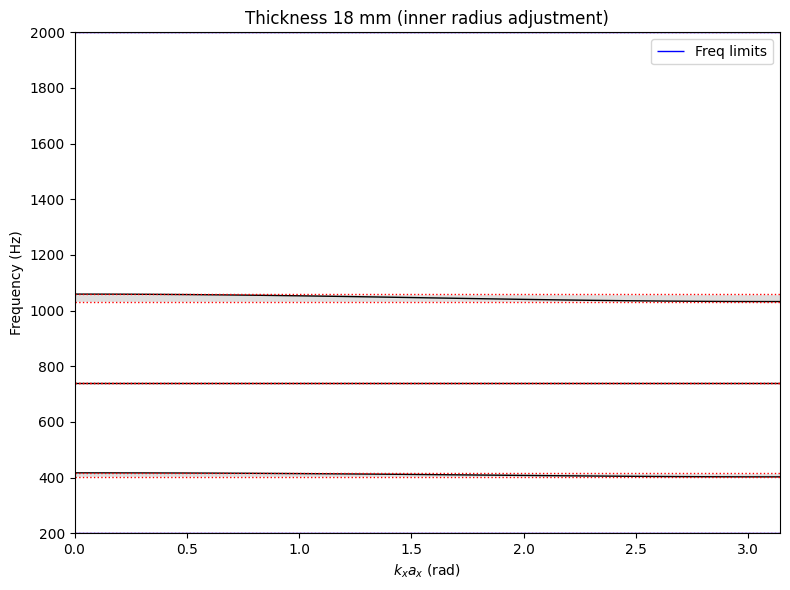

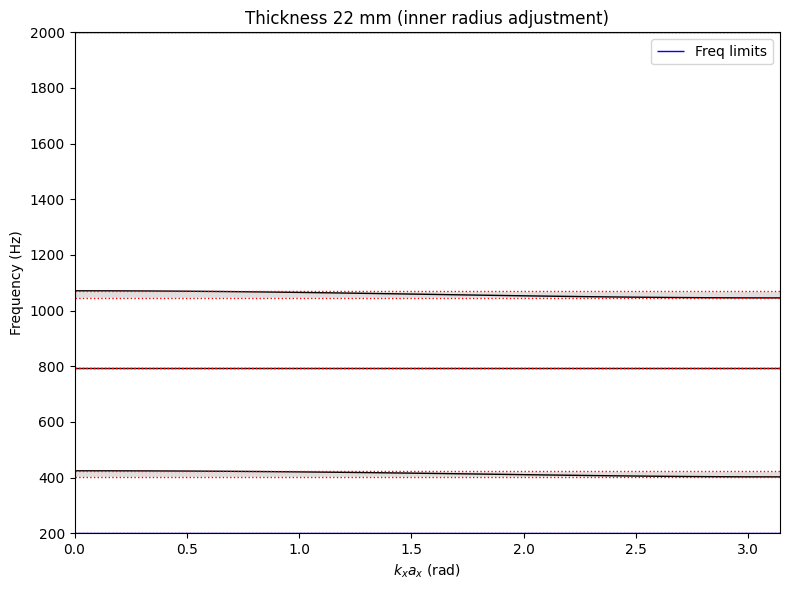

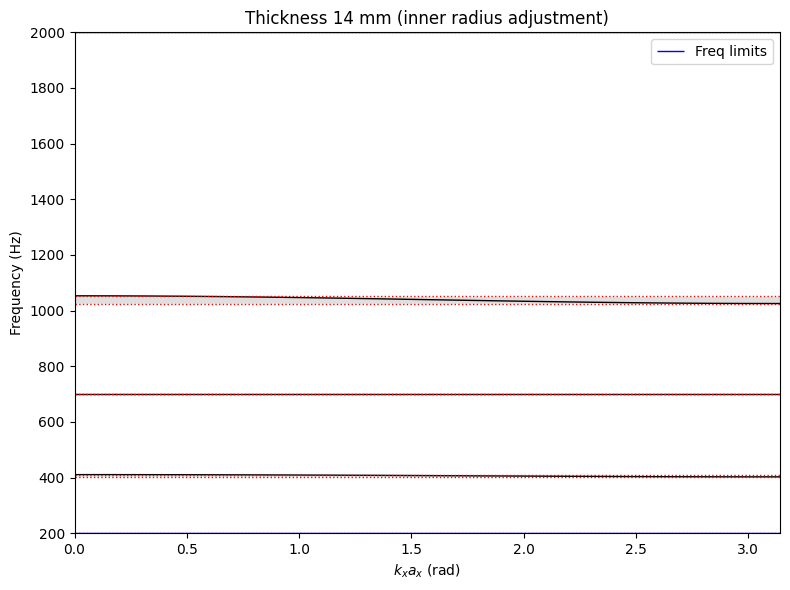

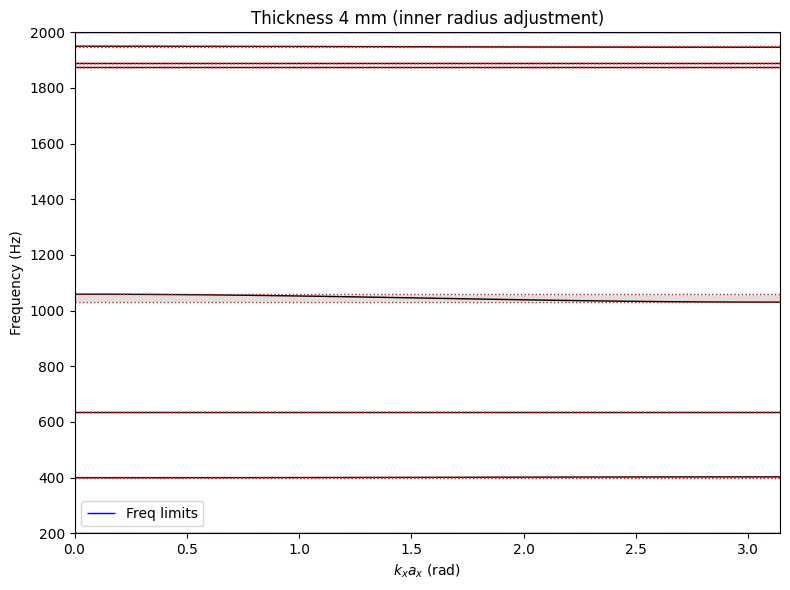

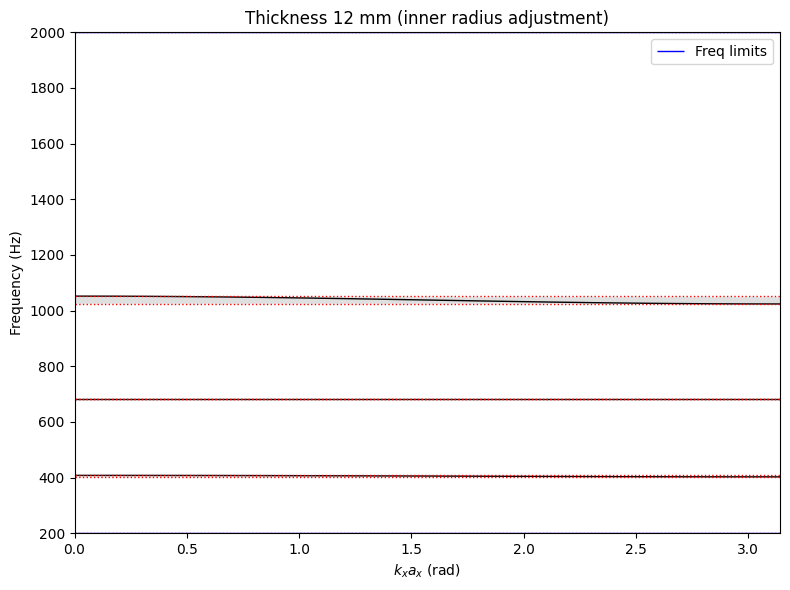

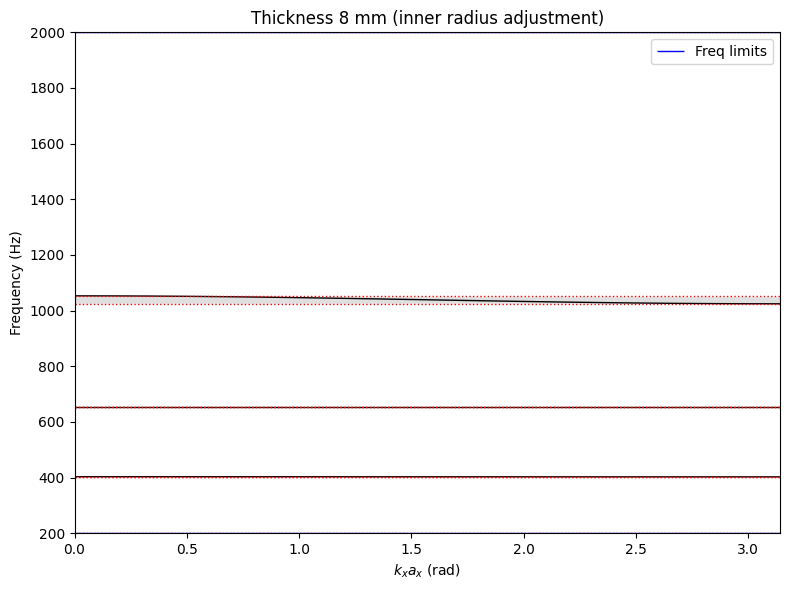

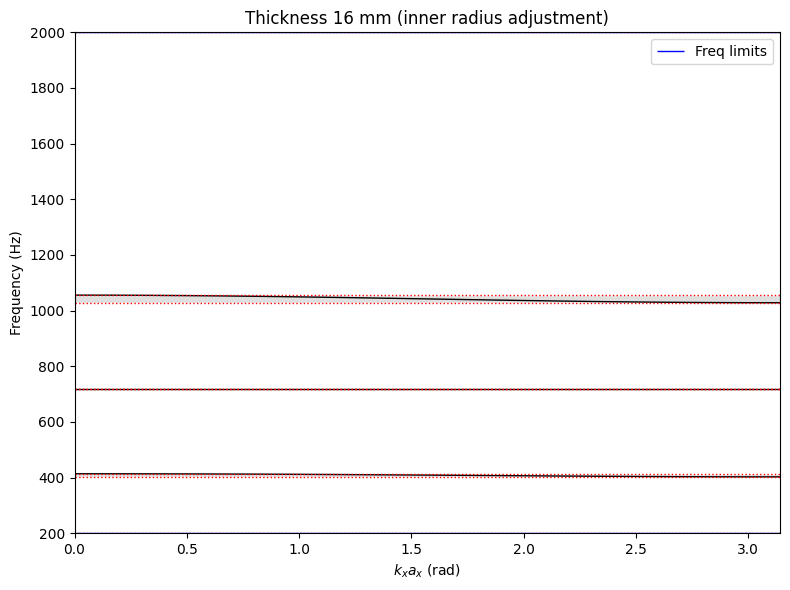

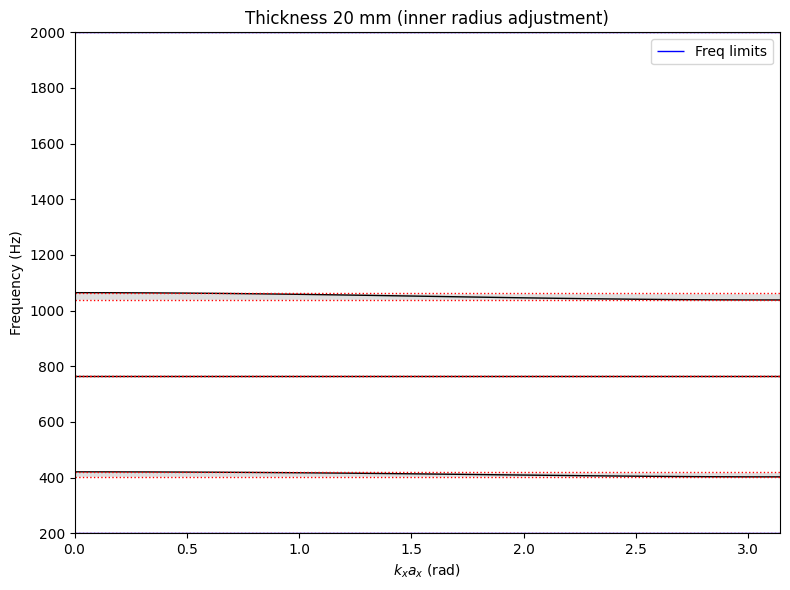

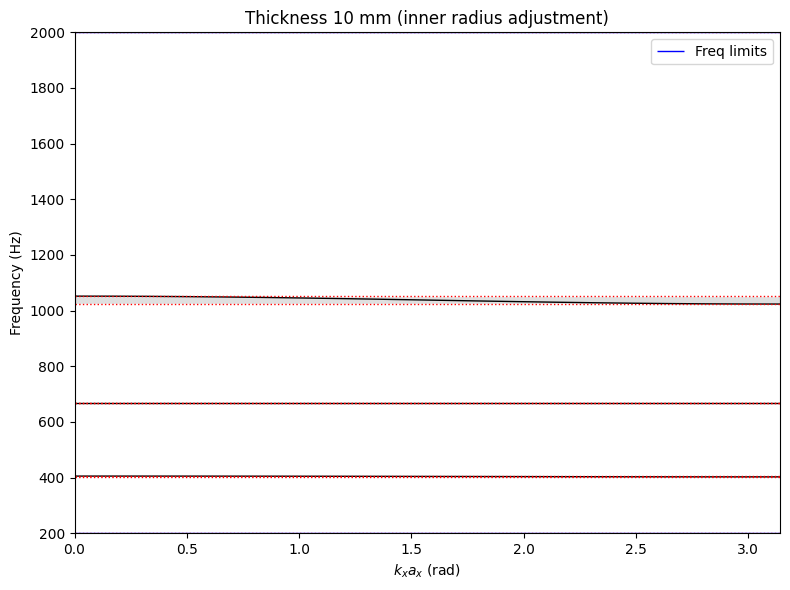

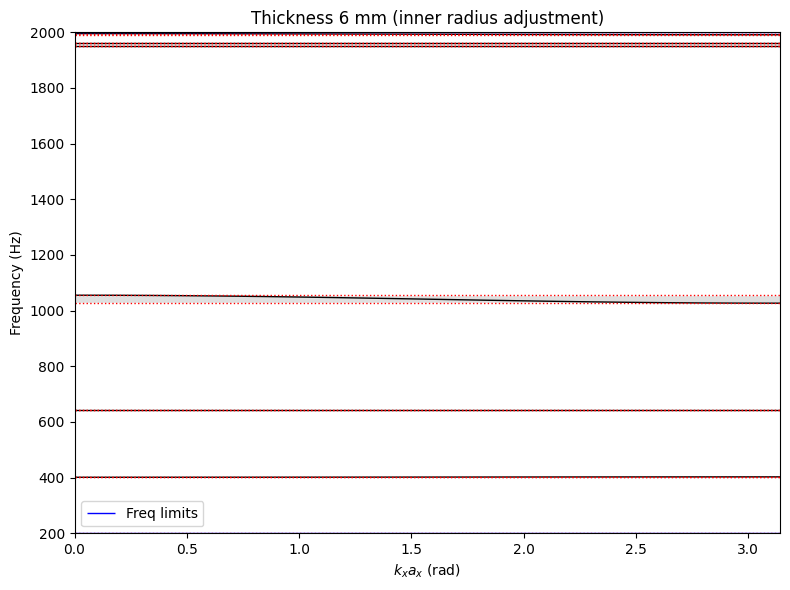

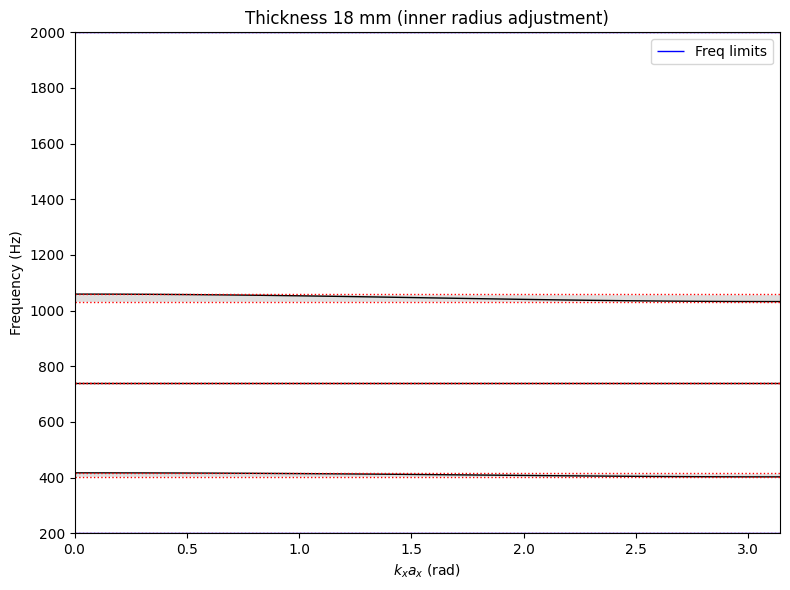

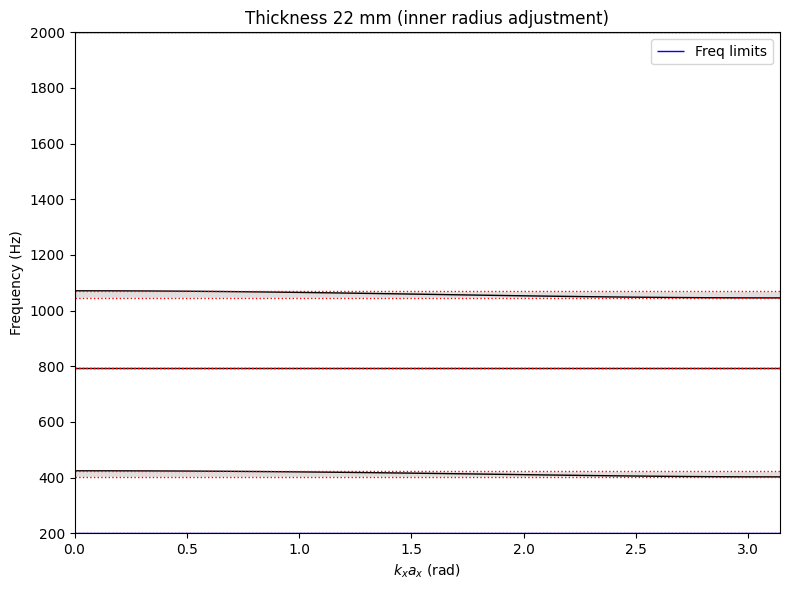

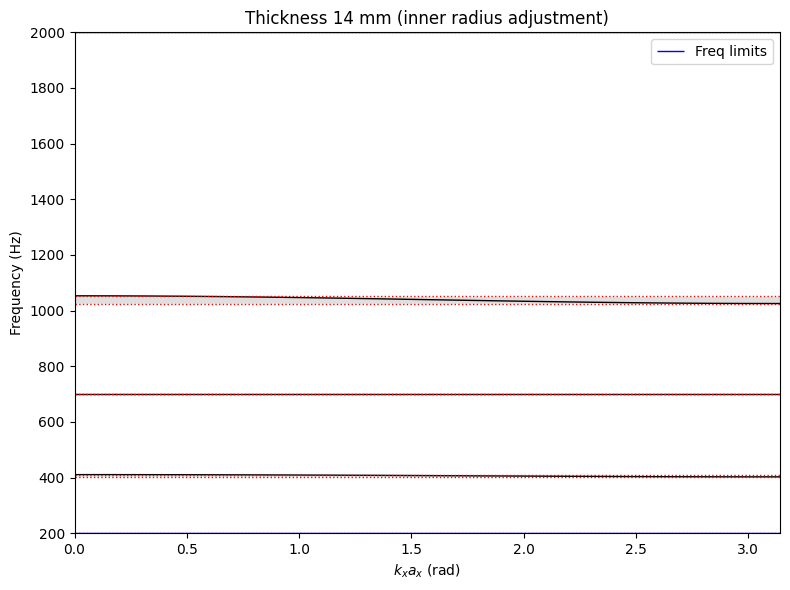

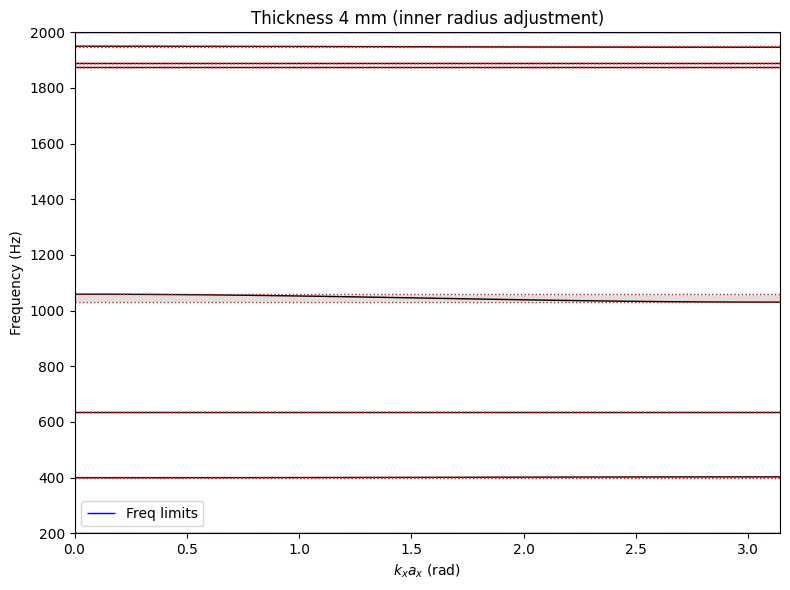

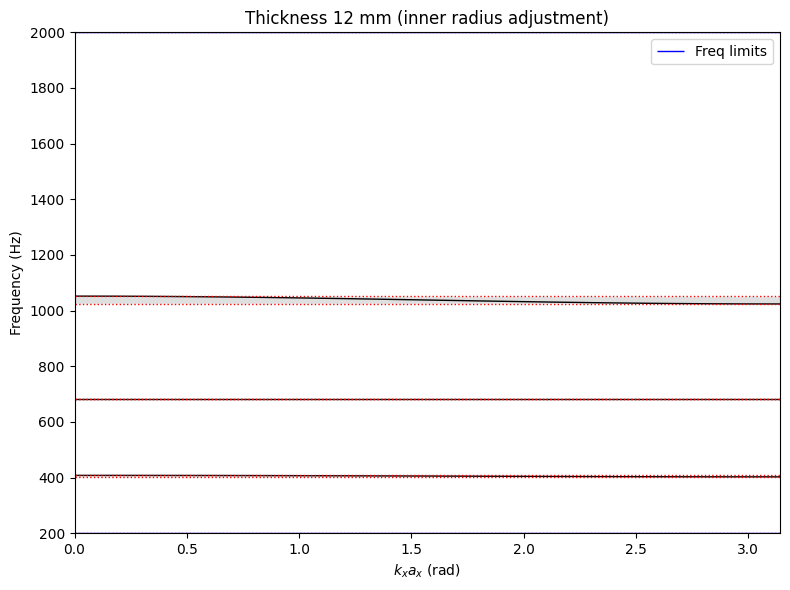

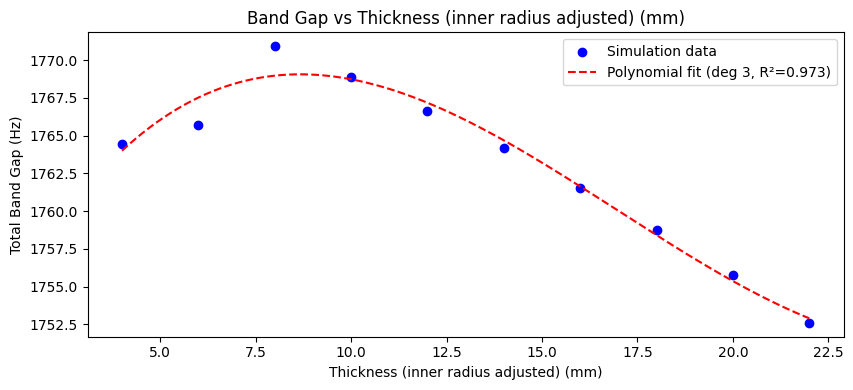

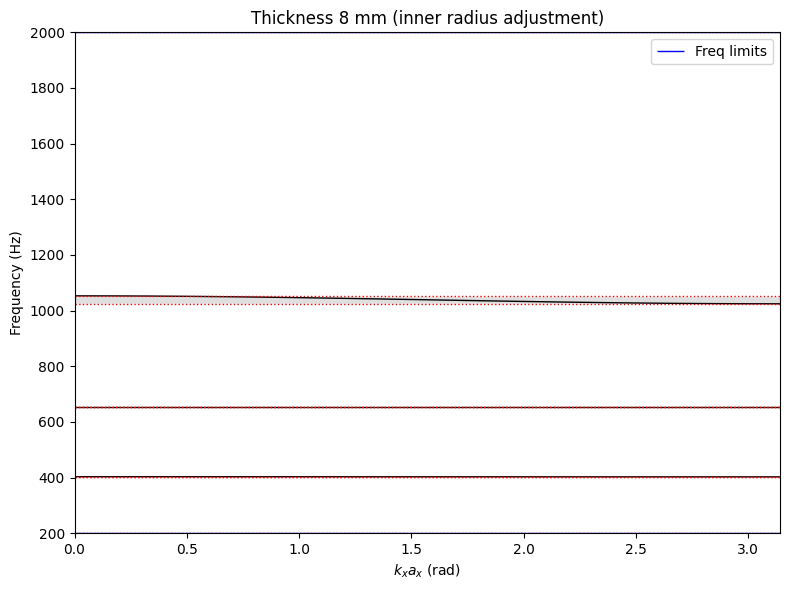

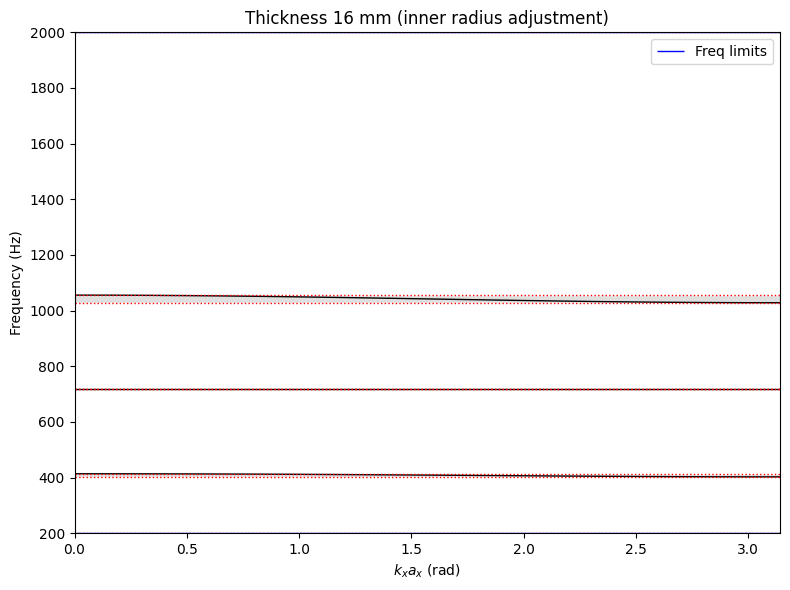

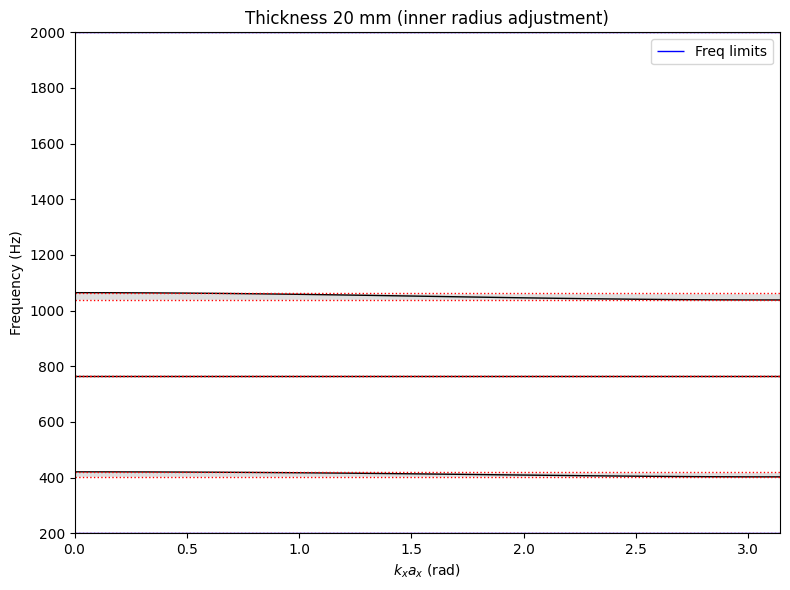

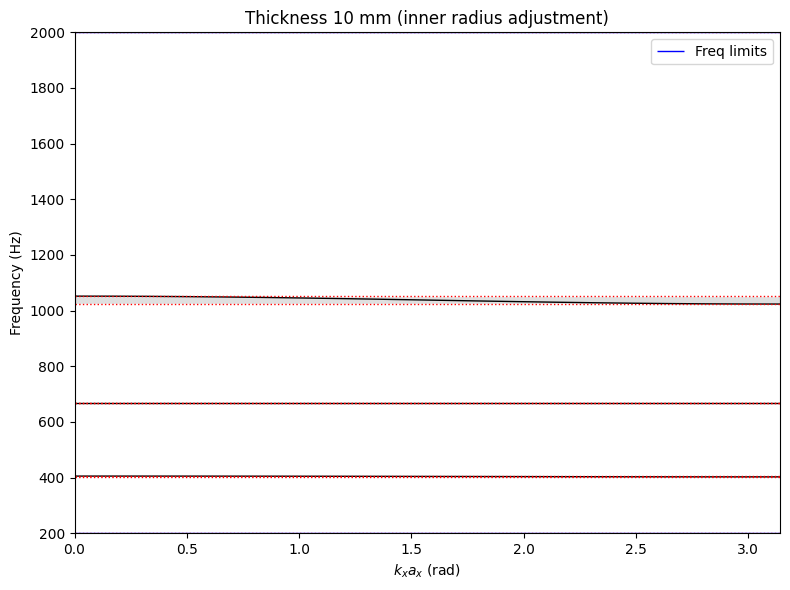

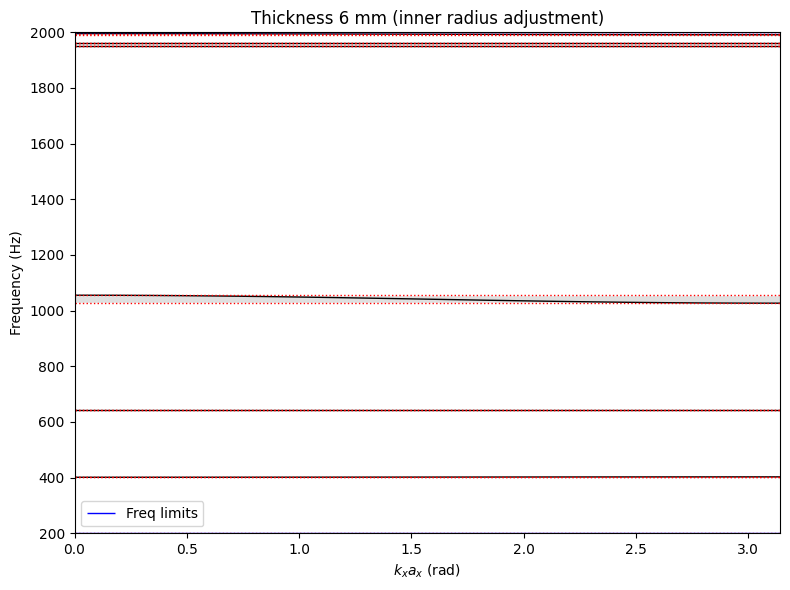

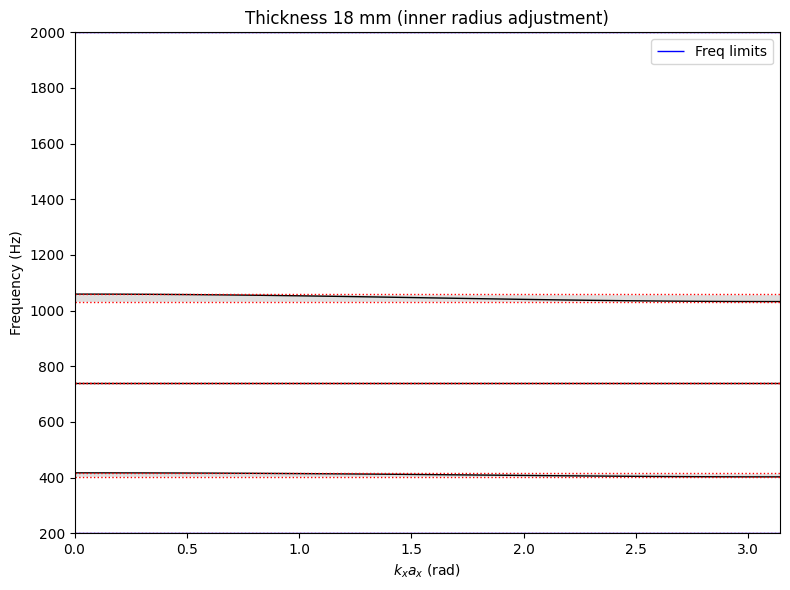

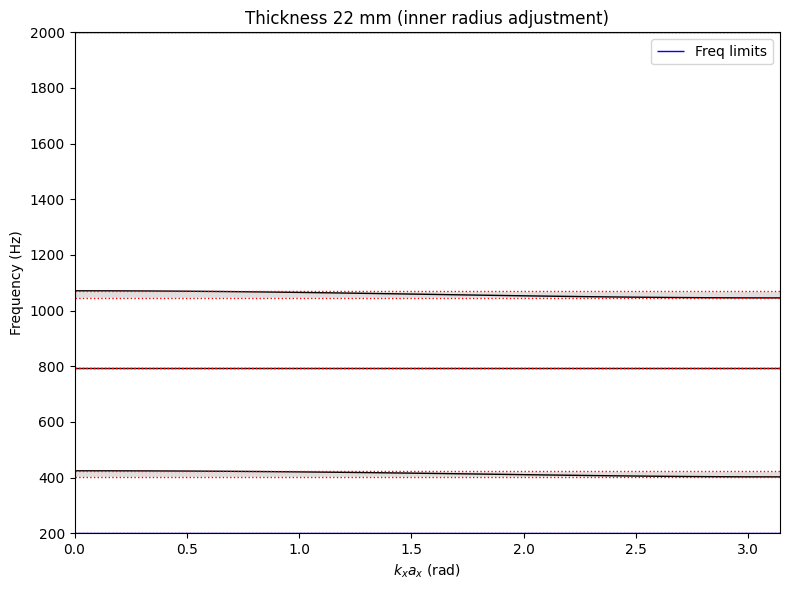

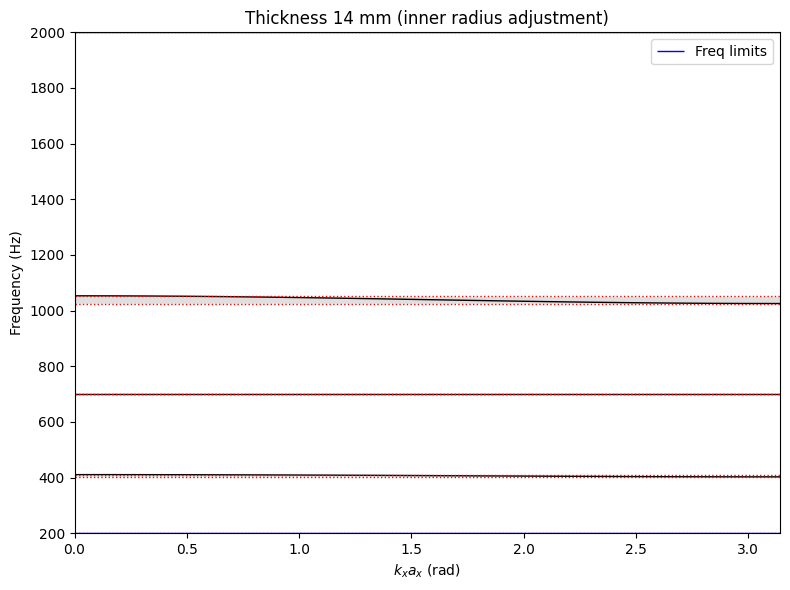

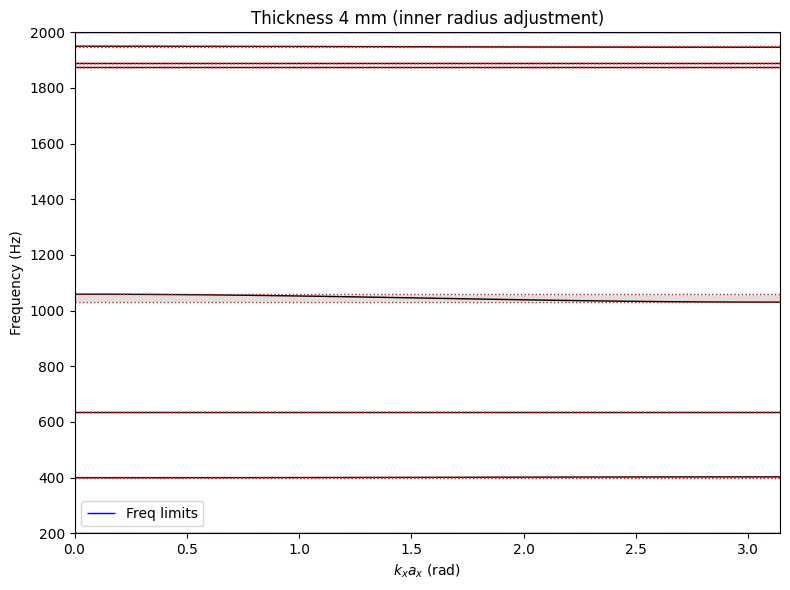

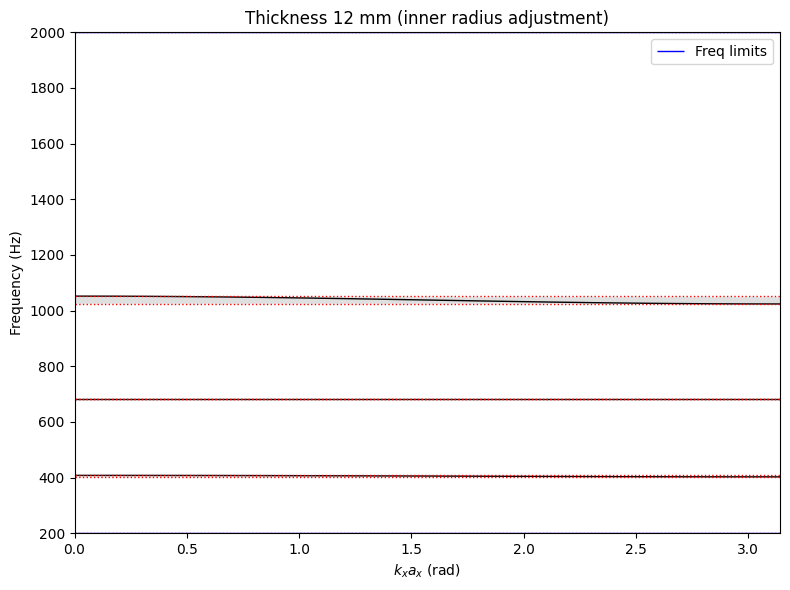

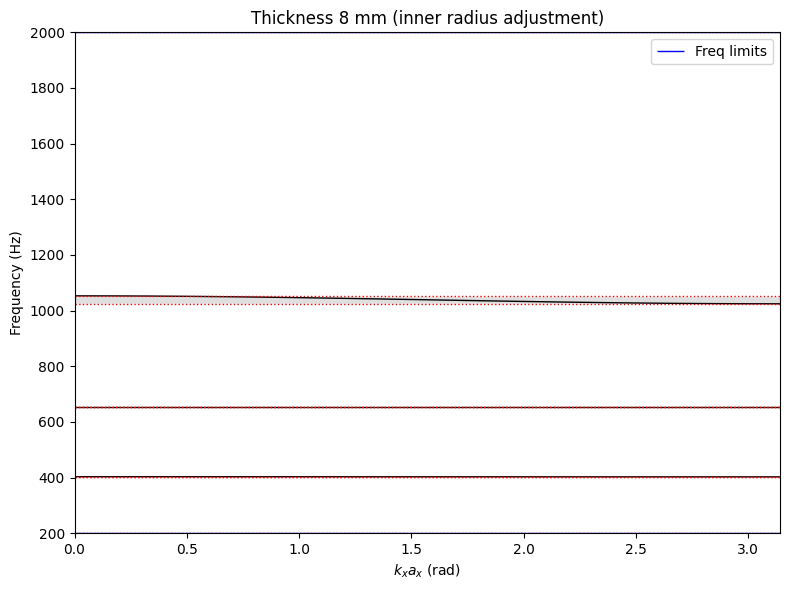

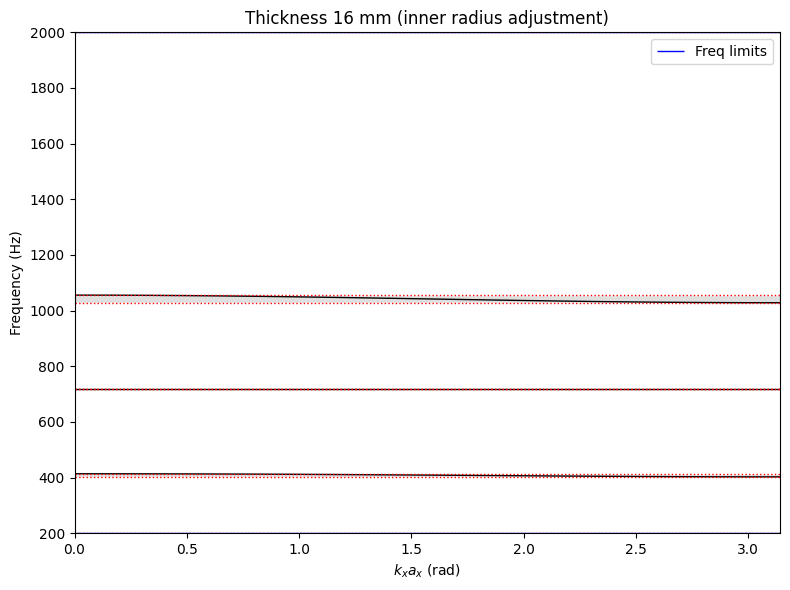

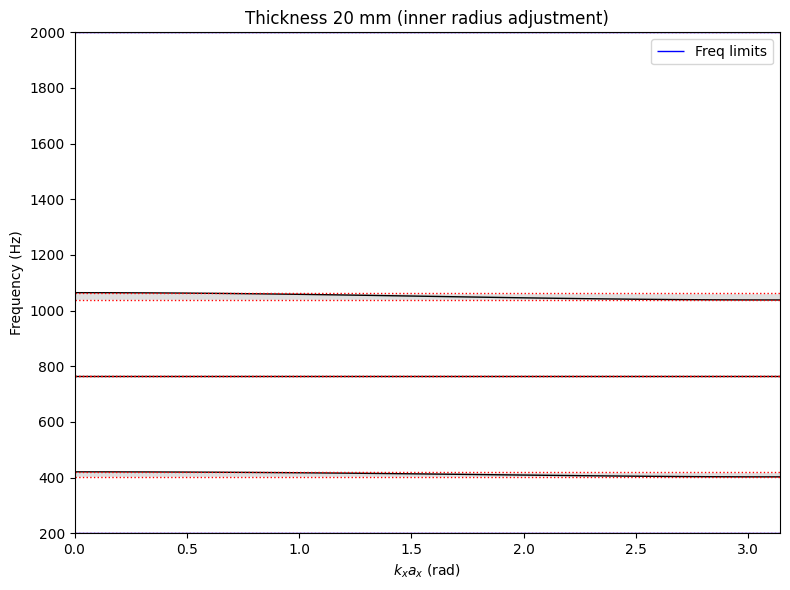

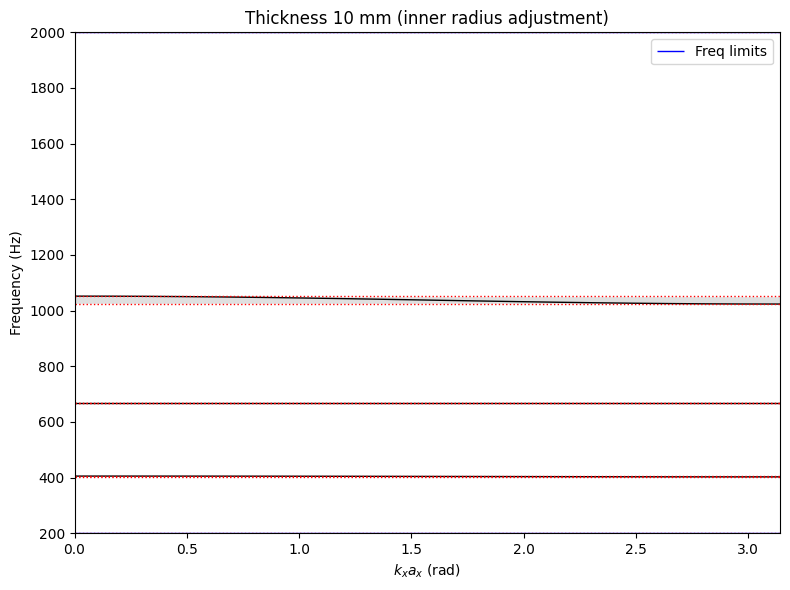

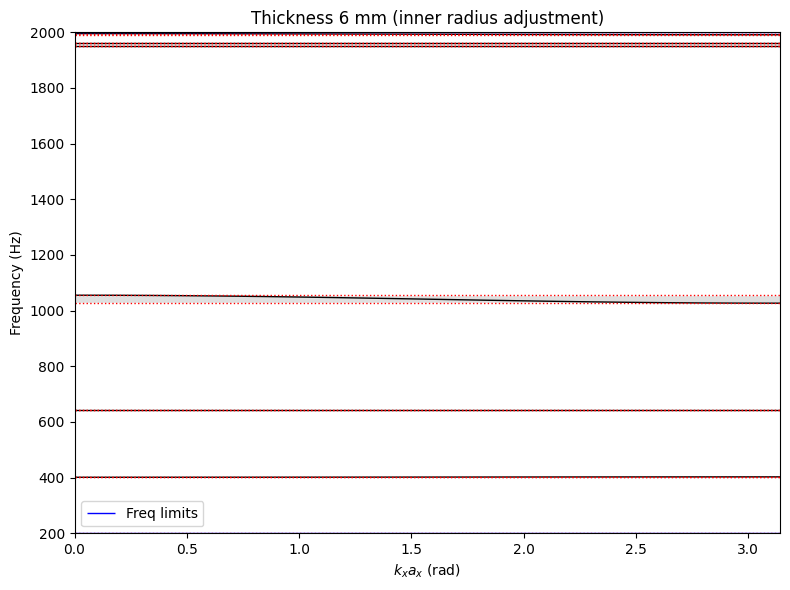

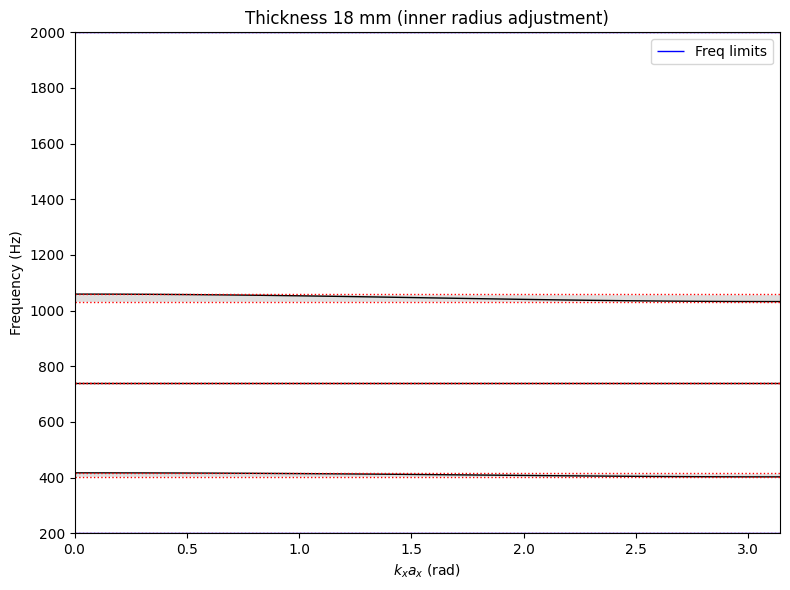

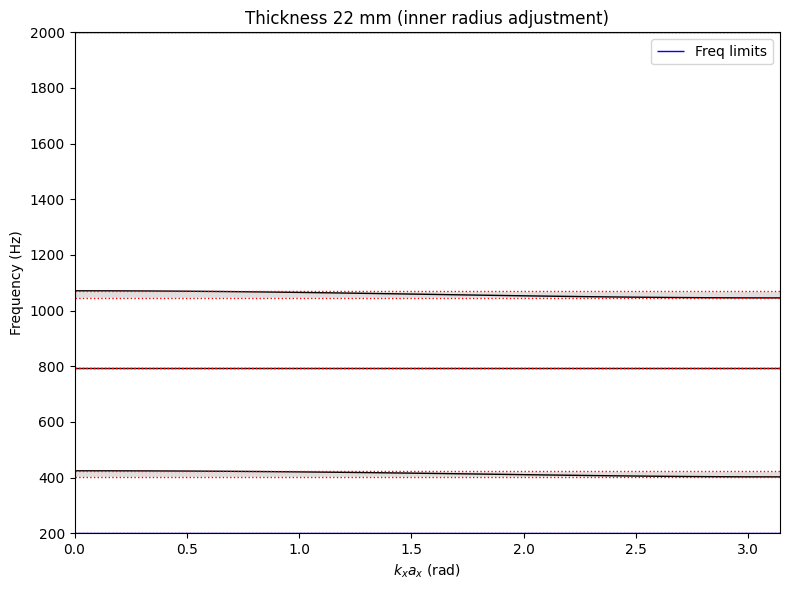

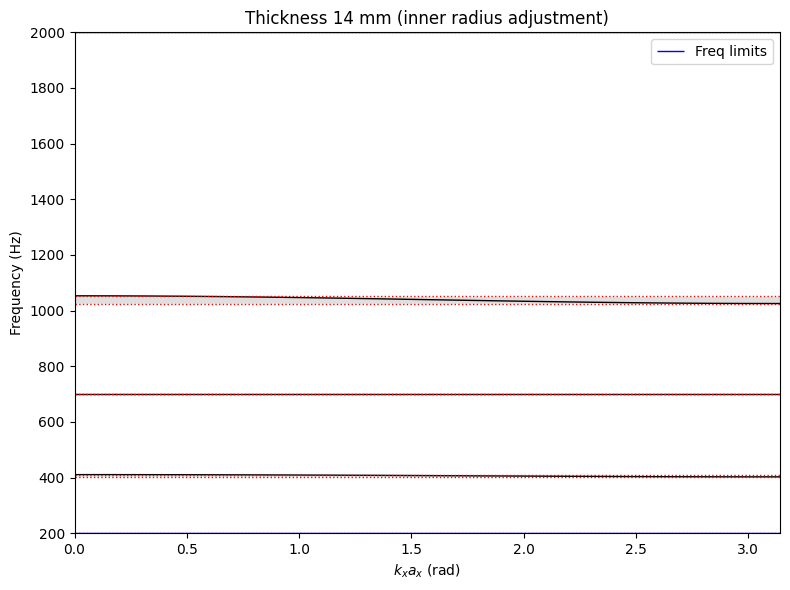

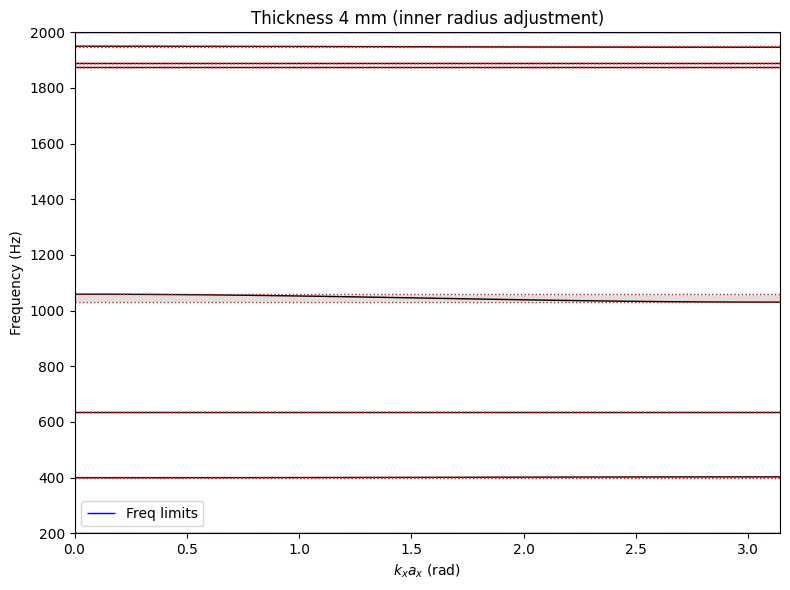

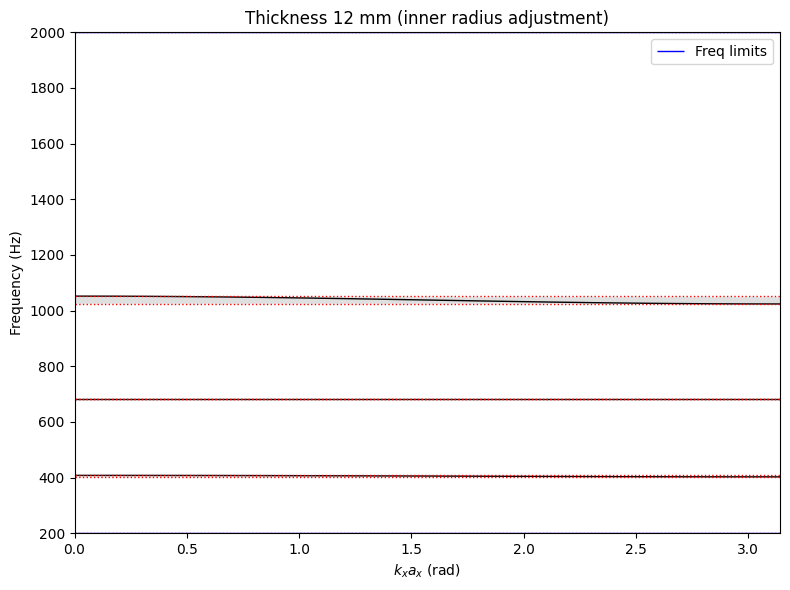

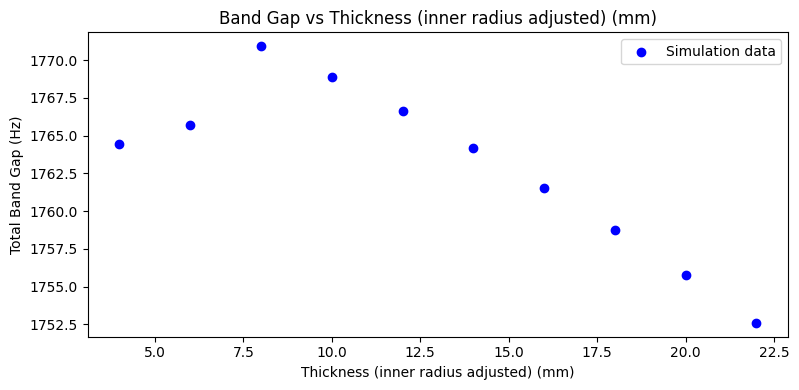

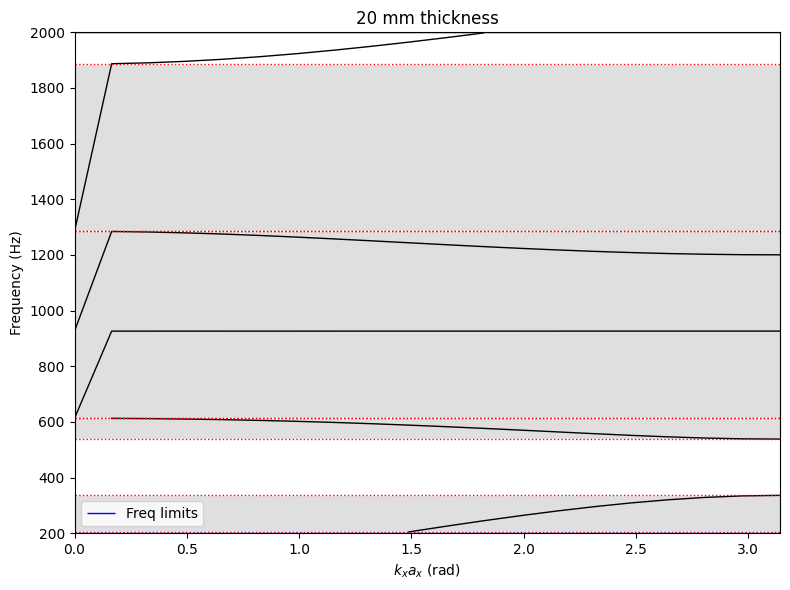

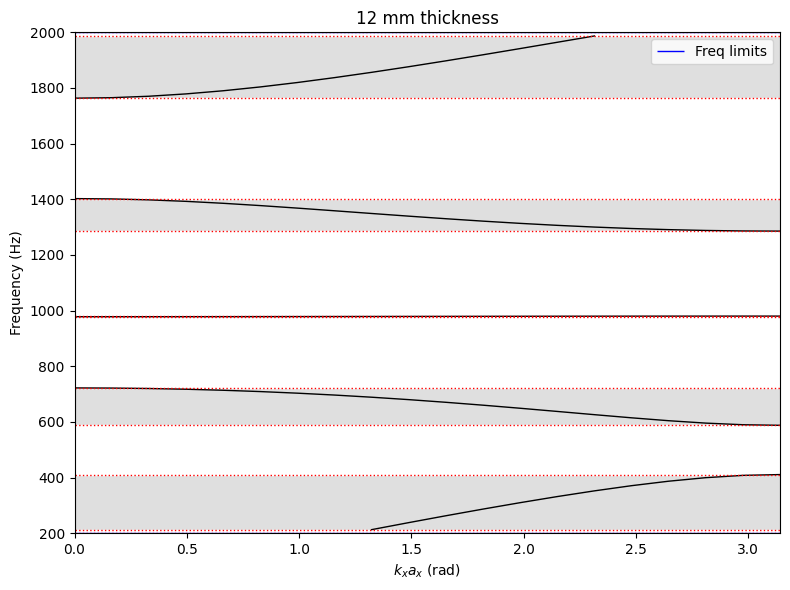

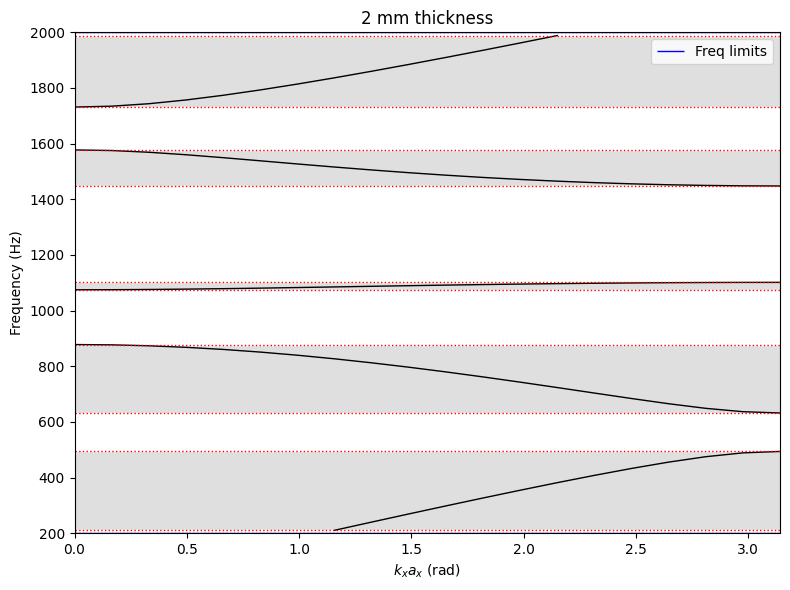

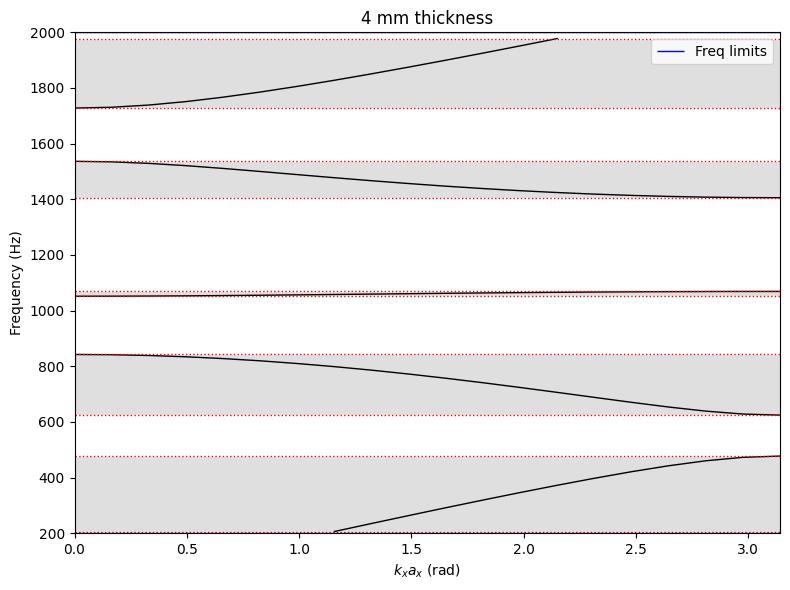

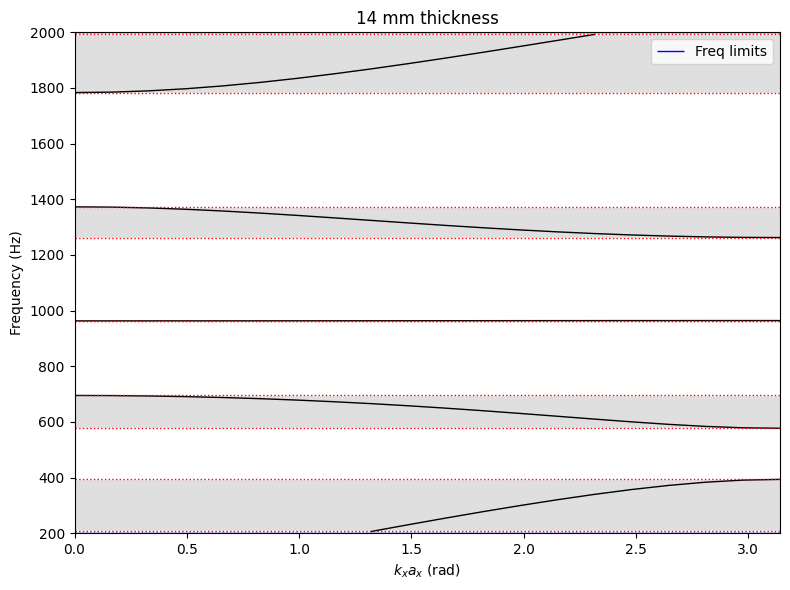

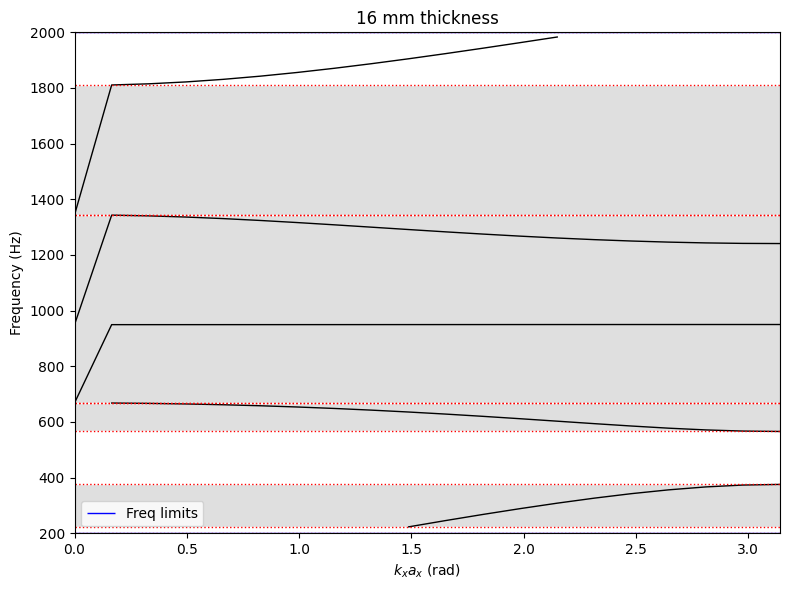

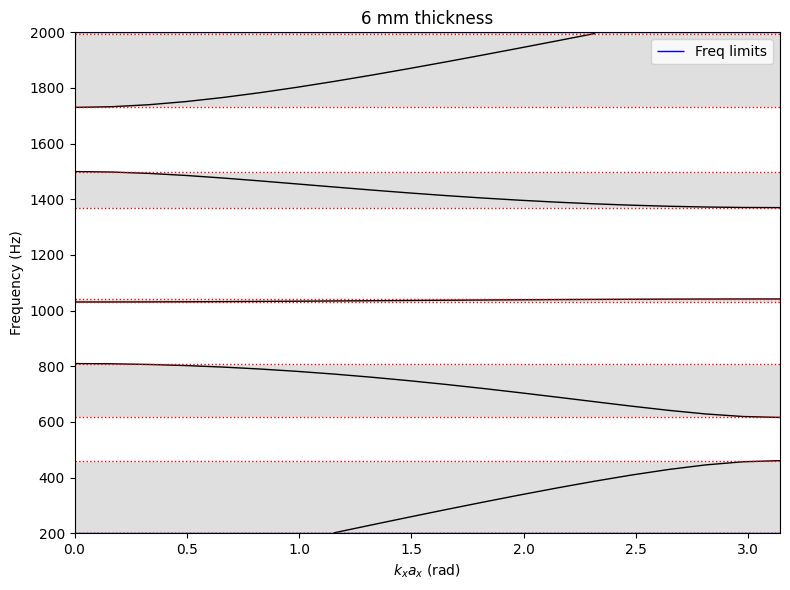

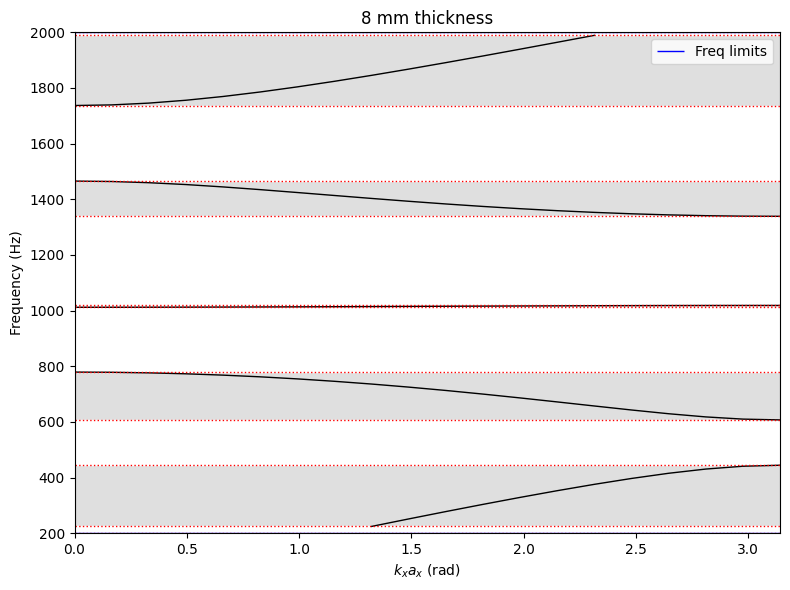

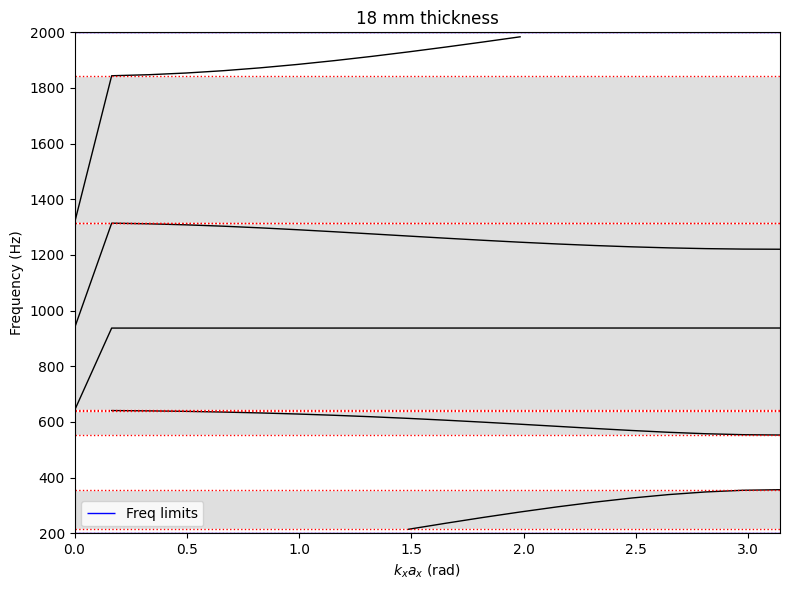

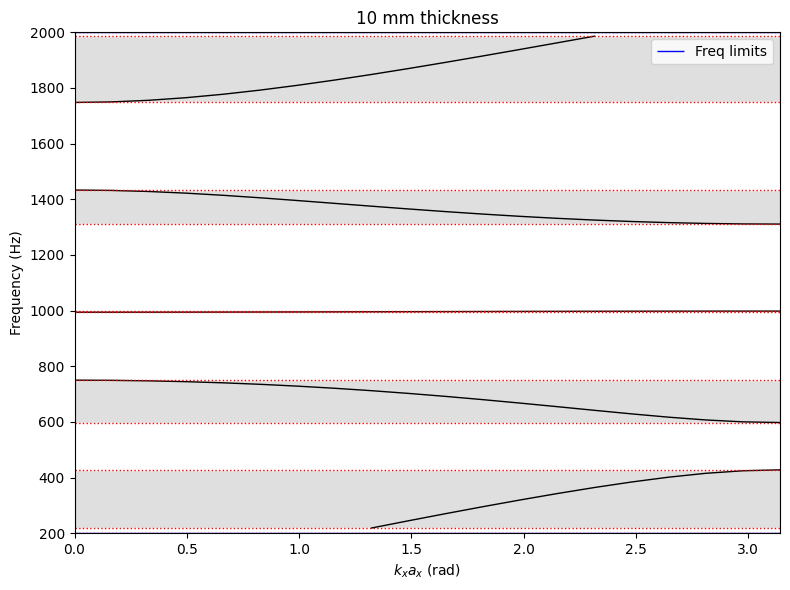

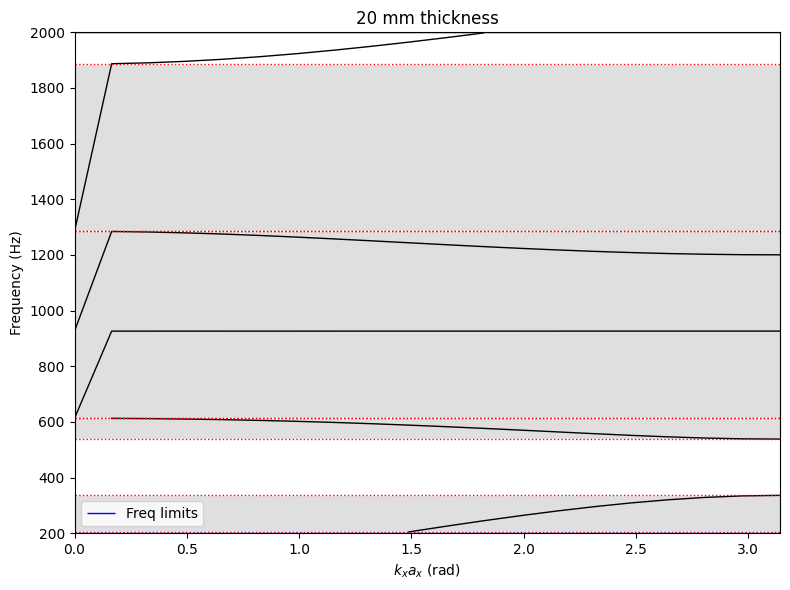

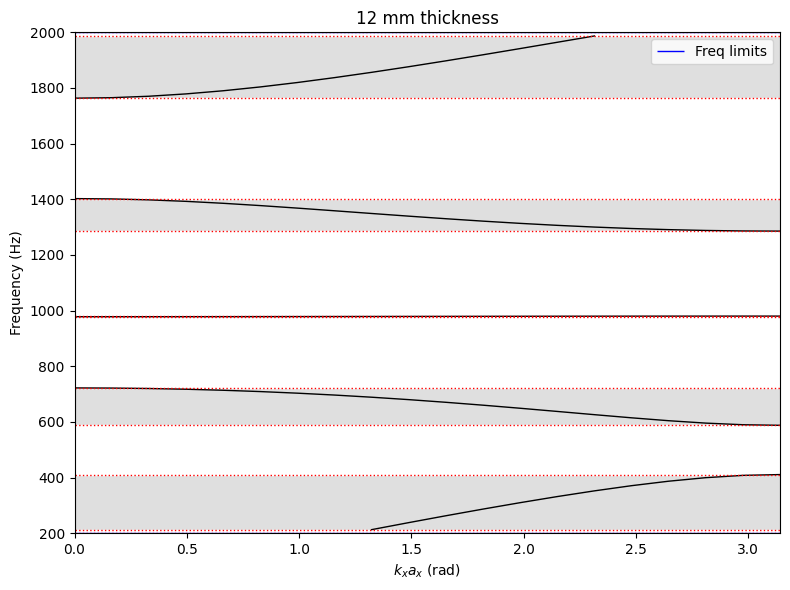

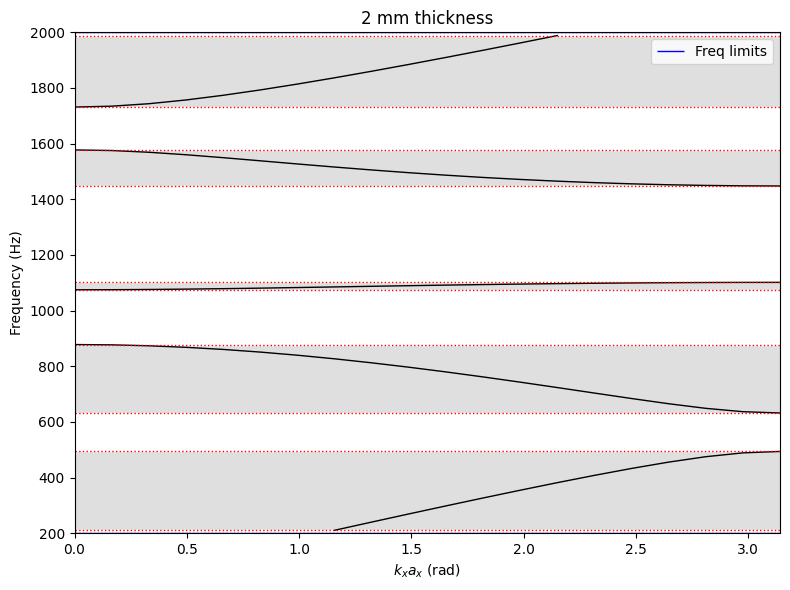

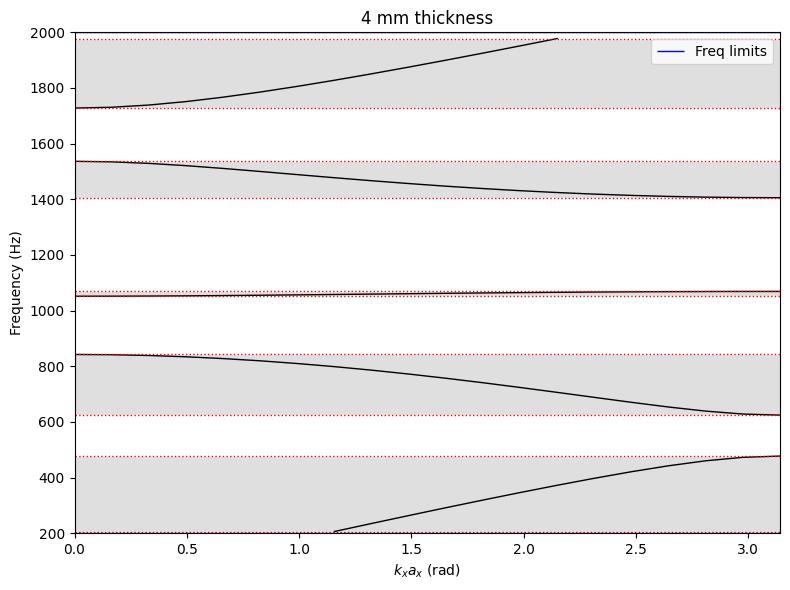

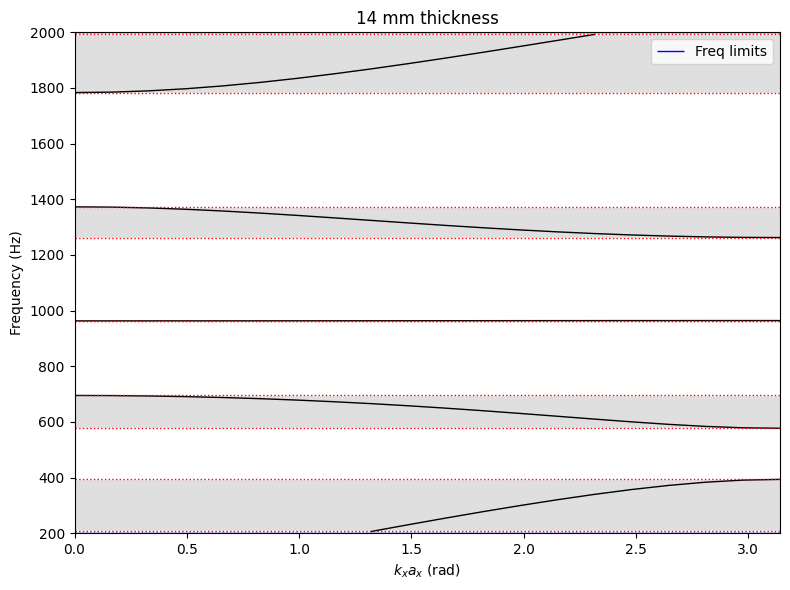

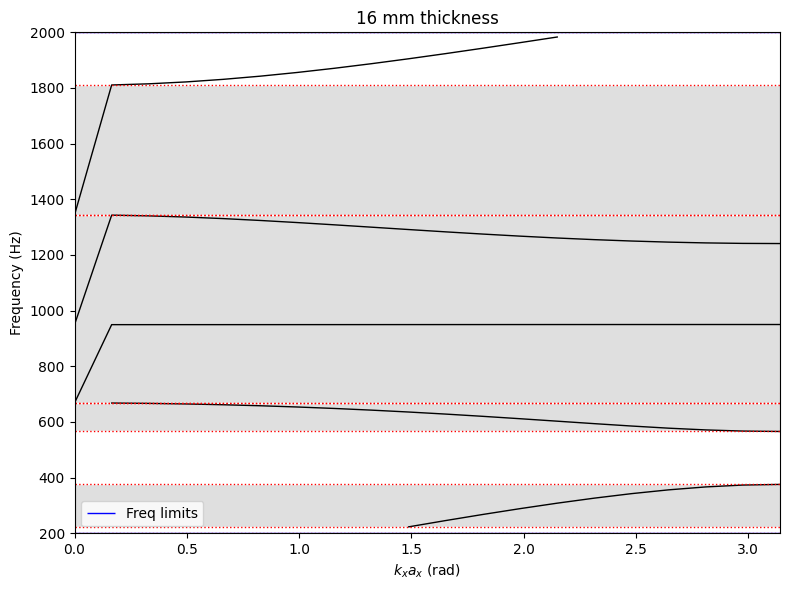

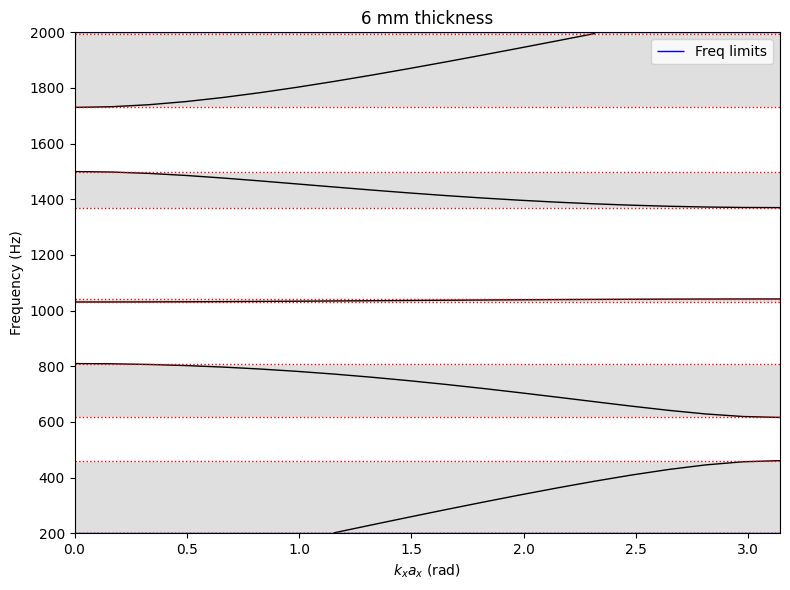

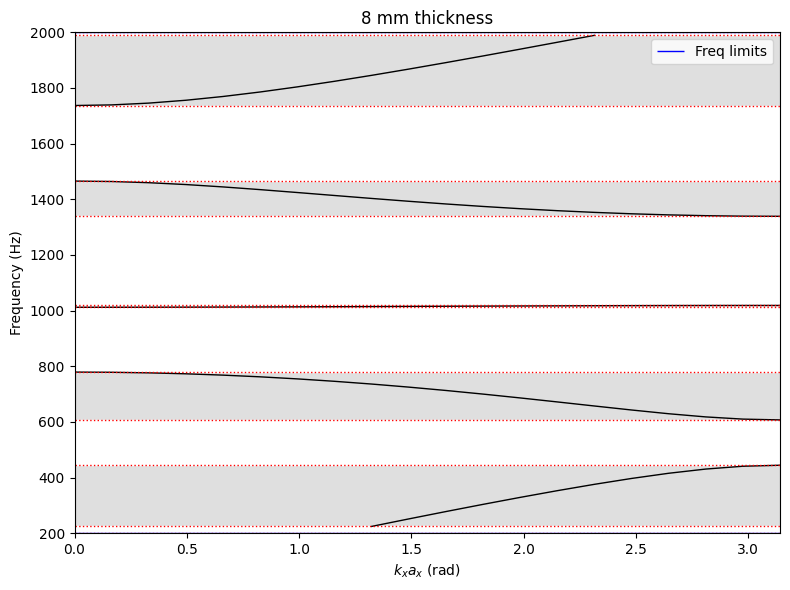

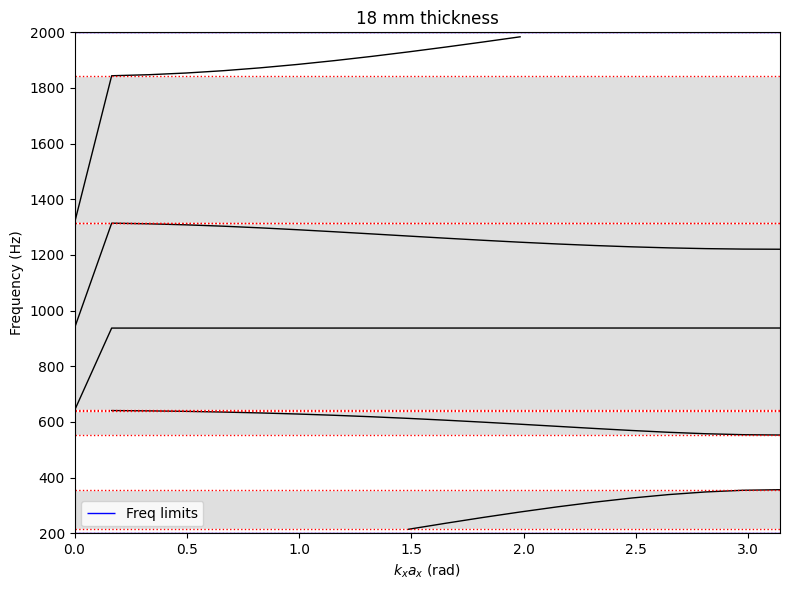

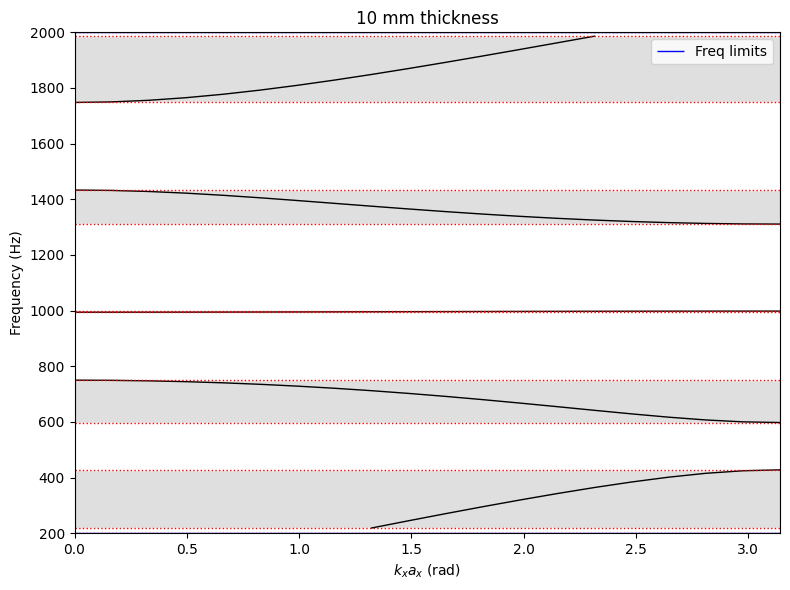

In [ ]:
class BandGapGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Band Gap Analyzer")
        self.root.geometry("900x600")

        # Options
        self.run_options = {
            "Inner Thickness": ("inner thickness", "Thickness (inner radius adjusted) (mm)"),
            "Outer Thickness": ("outer thickness", "Thickness (outer radius adjusted) (mm)"),
            "Separation": ("separation", "Separation (D) (mm)"),
            "Slit": ("slit", "Slit (W) (mm)")
        }

        # Selected run
        self.selected_run = tk.StringVar(value="Inner Thickness")
        self.plot_spectra = BooleanVar(value=False)
        self.fit_plot = BooleanVar(value=True)

        self._create_widgets()
        self.analyzer = None

    def _create_widgets(self):
        # Top frame for controls
        frame = ttk.Frame(self.root)
        frame.pack(side=tk.TOP, fill=tk.X, padx=10, pady=10)

        ttk.Label(frame, text="Select Run:").grid(row=0, column=0, padx=5)
        run_menu = ttk.OptionMenu(frame, self.selected_run, self.selected_run.get(), *self.run_options.keys())
        run_menu.grid(row=0, column=1, padx=5)

        ttk.Checkbutton(frame, text="Plot Spectra", variable=self.plot_spectra).grid(row=0, column=2, padx=5)
        ttk.Checkbutton(frame, text="Show Fit Plot", variable=self.fit_plot).grid(row=0, column=3, padx=5)

        ttk.Button(frame, text="Run Analysis", command=self.run_analysis).grid(row=0, column=4, padx=5)

        # Frame for matplotlib plot
        self.plot_frame = ttk.Frame(self.root)
        self.plot_frame.pack(fill=tk.BOTH, expand=True)

        # Frame for data table
        self.table_frame = ttk.Frame(self.root)
        self.table_frame.pack(fill=tk.X, padx=10, pady=10)

    def run_analysis(self):
        # Clear previous table and plot
        for widget in self.plot_frame.winfo_children():
            widget.destroy()
        for widget in self.table_frame.winfo_children():
            widget.destroy()

        folder, param_name = self.run_options[self.selected_run.get()]

        # Create analyzer instance
        self.analyzer = BandGapAnalyzer(folder=folder,
                                        param_name=param_name,
                                        plot_spectra=self.plot_spectra.get())
        self.analyzer._collect_data(display_data=False)

        # Display table
        self._display_table()

        # Display plot
        self._display_plot()

    def _display_table(self):
        data = self.analyzer.data
        cols = list(data.columns)

        tree = ttk.Treeview(self.table_frame, columns=cols, show='headings', height=6)
        for col in cols:
            tree.heading(col, text=col)
            tree.column(col, width=120)
        for _, row in data.iterrows():
            tree.insert("", "end", values=list(row))
        tree.pack(fill=tk.X)

    def _display_plot(self):
        fig, ax = plt.subplots(figsize=(7,4))
        x = self.analyzer.data[self.analyzer.param_name]
        y = self.analyzer.data['Total Band Gap (Hz)']

        ax.scatter(x, y, color='blue', label='Simulation data')

        if self.fit_plot.get():
            best_degree, best_coeffs, best_r2 = self.analyzer.best_fit()
            x_smooth = np.linspace(x.min(), x.max(), 200)
            y_smooth = np.polyval(best_coeffs, x_smooth)
            ax.plot(x_smooth, y_smooth, color='red', linestyle='--',
                    label=f'Polynomial fit (deg {best_degree}, R²={best_r2:.3f})')

        ax.set_xlabel(self.analyzer.param_name)
        ax.set_ylabel('Total Band Gap (Hz)')
        ax.set_title(f'Band Gap vs {self.analyzer.param_name}')
        ax.legend()
        fig.tight_layout()

        canvas = FigureCanvasTkAgg(fig, master=self.plot_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)


# Run the GUI
if __name__ == "__main__":
    root = tk.Tk()
    app = BandGapGUI(root)
    root.mainloop()